# Environment Setup

This notebook generates the complete synthetic dataset for the MaternaLink prototype: master data (facilities, drugs, conditions, knowledge bases), three years of monthly transactional history (pregnancy context, diagnoses, stock movements), and a corpus of synthetic anamnesis transcripts with ground truth labels for evaluating the Layer 0 extraction pipeline.

All correlations are enforced by design through a rule-based probabilistic simulator: malaria incidence rises in endemic facilities during the rainy season, resupply fails for hard-to-reach facilities during monsoon months, and drug consumption is derived mechanistically from case counts, dosing, and treatment duration. The simulator is fully seeded and reproducible.

## Drive Mount and Base Path

In [1]:
"""Mount Google Drive when running on Colab. Outside Colab the notebook falls
back to a local directory so the full pipeline can be tested end to end."""

import os

try:
    from google.colab import drive
    drive.mount('/content/drive')

    """Base path untuk Google Drive storage"""
    base_path = '/content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton'
except ModuleNotFoundError:
    base_path = os.environ.get(
        'MATERNALINK_DATA_ROOT',
        os.path.abspath(os.path.join(os.getcwd(), '..', 'drive_local')),
    )

DATA_DIRS = {
    name: os.path.join(base_path, 'data', name)
    for name in [
        'master', 'transactional', 'layer0_output',
        'layer1_mock', 'layer2_output', 'audio_demo', 'eval',
    ]
}
for path in DATA_DIRS.values():
    os.makedirs(path, exist_ok=True)

print(f'Base path: {base_path}')

Mounted at /content/drive
Base path: /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton


## Library Imports and Global Configuration

The simulation horizon covers thirty six monthly periods. Anamnesis records exist only from January 2025 onward, reflecting the narrative that the speech based reporting module was deployed in the final year of the historical window. The rainy season in the simulated region spans October through March.

In [2]:
"""Global imports, random seed, and simulation constants."""

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

N_FACILITIES = 10
PERIODS = pd.date_range('2023-01-01', '2025-12-01', freq='MS')
RAINY_MONTHS = {10, 11, 12, 1, 2, 3}
ANAMNESIS_START = pd.Timestamp('2025-01-01')
FORECAST_PERIOD = pd.Timestamp('2026-01-01')

pd.set_option('display.max_columns', None)
print(f'{len(PERIODS)} monthly periods from {PERIODS[0].date()} to {PERIODS[-1].date()}')

36 monthly periods from 2023-01-01 to 2025-12-01


# Master Data Generation

## Facilities

The simulated district mirrors a single IFK (district pharmaceutical warehouse) serving thirty puskesmas in an eastern Indonesian district. Remoteness drives every structural attribute: distance to the IFK, lead time, accessibility scores, laboratory and cold chain availability, regional maternal mortality, and rainy season access. Sixty percent of facilities are remote or very remote, deliberately oversampling the high risk profile that motivates the product.

In [3]:
"""Facility master table. Attribute distributions are conditioned on the
remoteness profile so that structural disadvantage is internally consistent."""

VILLAGE_NAMES = [
    'Ruteng', 'Reok', 'Wae Nakeng', 'Cancar', 'Iteng',
    'Narang', 'Wangko', 'Dintor', 'Lembor', 'Werang',
]
SUBDISTRICTS = ['Ruteng', 'Lembor', 'Cibal', 'Reok', 'Satar Mese', 'Wae Rii']

REMOTENESS_PROFILE = {
    'ordinary': dict(
        distance=(5, 40), lead_time=(2, 4), access_score=3,
        rainy_access=['normal', 'normal', 'disrupted'],
        p_lab=0.90, p_cold_chain=0.95, p_endemic=0.30,
        mmr=(180, 320), pregnancies=(60, 120),
    ),
    'remote': dict(
        distance=(40, 90), lead_time=(4, 9), access_score=2,
        rainy_access=['normal', 'disrupted', 'disrupted'],
        p_lab=0.50, p_cold_chain=0.60, p_endemic=0.55,
        mmr=(280, 480), pregnancies=(40, 90),
    ),
    'very_remote': dict(
        distance=(80, 150), lead_time=(7, 16), access_score=1,
        rainy_access=['disrupted', 'cut_off', 'cut_off'],
        p_lab=0.20, p_cold_chain=0.30, p_endemic=0.75,
        mmr=(420, 650), pregnancies=(20, 60),
    ),
}

remoteness_assignment = (
    ['ordinary'] * 4 + ['remote'] * 3 + ['very_remote'] * 3
)
rng.shuffle(remoteness_assignment)

facility_rows = []
for idx, (village, remoteness) in enumerate(zip(VILLAGE_NAMES, remoteness_assignment), start=1):
    profile = REMOTENESS_PROFILE[remoteness]
    pregnancies = int(rng.integers(*profile['pregnancies']))
    has_cold_chain = bool(rng.random() < profile['p_cold_chain'])
    facility_rows.append({
        'facility_id': f'PKM-{idx:03d}',
        'name': f'Puskesmas {village}',
        'district': f'Kecamatan {rng.choice(SUBDISTRICTS)}',
        'province': 'Nusa Tenggara Timur',
        'remoteness': remoteness,
        'is_malaria_endemic': bool(rng.random() < profile['p_endemic']),
        'has_lab': bool(rng.random() < profile['p_lab']),
        'has_cold_chain': has_cold_chain,
        'storage_capacity_total': int(pregnancies * rng.uniform(24, 40)),
        'cold_chain_capacity': int(rng.uniform(40, 150)) if has_cold_chain else 0,
        'distance_to_ifk_km': round(float(rng.uniform(*profile['distance'])), 1),
        'lead_time_days': round(float(rng.uniform(*profile['lead_time'])), 1),
        'accessibility_score': profile['access_score'],
        'rainy_season_access': str(rng.choice(profile['rainy_access'])),
        'regional_mmr': round(float(rng.uniform(*profile['mmr'])), 1),
        'baseline_pregnancy_count': pregnancies,
    })

facilities = pd.DataFrame(facility_rows)
facilities.head()

,facility_id,name,district,province,remoteness,is_malaria_endemic,has_lab,has_cold_chain,storage_capacity_total,cold_chain_capacity,distance_to_ifk_km,lead_time_days,accessibility_score,rainy_season_access,regional_mmr,baseline_pregnancy_count
0,PKM-001,Puskesmas Ruteng,Kecamatan Satar Mese,Nusa Tenggara Timur,remote,True,True,False,2274,0,86.3,7.2,2,disrupted,368.7,76
1,PKM-002,Puskesmas Reok,Kecamatan Ruteng,Nusa Tenggara Timur,remote,True,False,True,2762,123,57.7,8.9,2,disrupted,458.6,81
2,PKM-003,Puskesmas Wae Nakeng,Kecamatan Satar Mese,Nusa Tenggara Timur,ordinary,False,True,True,2646,115,31.1,3.9,3,normal,231.9,100
3,PKM-004,Puskesmas Cancar,Kecamatan Satar Mese,Nusa Tenggara Timur,very_remote,True,False,False,911,0,126.9,10.9,1,disrupted,611.5,33
4,PKM-005,Puskesmas Iteng,Kecamatan Satar Mese,Nusa Tenggara Timur,ordinary,False,True,True,2929,71,28.9,2.3,3,disrupted,181.0,97


## Drug Catalog

Thirty maternal drugs from the project formulary. The dosing figures are simulation parameters used to translate case counts into unit demand, not clinical guidance. Cold chain requirements drive a dedicated allocation constraint in Layer 2.

In [4]:
"""Drug master table. Columns standard_daily_dose and treatment_duration_days
parameterize the demand translation cases x dose x duration."""

DRUG_ROWS = [
    ('OBT-001', 'Quinine', 'essential', 'tablet', False, 6, 7),
    ('OBT-002', 'Clindamycin', 'essential', 'capsule', False, 3, 7),
    ('OBT-003', 'Artemisinin Combination Therapy', 'essential', 'tablet', False, 4, 3),
    ('OBT-004', 'High Dose Iron', 'essential', 'tablet', False, 2, 30),
    ('OBT-005', 'Vitamin B12', 'routine', 'tablet', False, 1, 30),
    ('OBT-006', 'Folic Acid Supplement', 'routine', 'tablet', False, 1, 30),
    ('OBT-007', 'Glucose Oral IV', 'emergency', 'vial', True, 2, 2),
    ('OBT-008', 'Nifedipine', 'essential', 'tablet', False, 3, 14),
    ('OBT-009', 'Methyldopa', 'essential', 'tablet', False, 3, 14),
    ('OBT-010', 'Magnesium Sulfate', 'emergency', 'vial', True, 4, 2),
    ('OBT-011', 'Insulin', 'emergency', 'vial', True, 1, 30),
    ('OBT-012', 'Metformin', 'essential', 'tablet', False, 2, 30),
    ('OBT-013', 'Amoxicillin', 'essential', 'capsule', False, 3, 7),
    ('OBT-014', 'Cephalexin', 'essential', 'capsule', False, 4, 7),
    ('OBT-015', 'Ondansetron', 'essential', 'tablet', False, 3, 5),
    ('OBT-016', 'Pyridoxine Vitamin B6', 'routine', 'tablet', False, 3, 14),
    ('OBT-017', 'Antacid', 'routine', 'tablet', False, 3, 14),
    ('OBT-018', 'Levothyroxine', 'essential', 'tablet', False, 1, 30),
    ('OBT-019', 'Antiretroviral', 'emergency', 'tablet', True, 1, 30),
    ('OBT-020', 'Cotrimoxazole', 'essential', 'tablet', False, 1, 30),
    ('OBT-021', 'Tenofovir', 'essential', 'tablet', False, 1, 30),
    ('OBT-022', 'Metronidazole', 'essential', 'tablet', False, 2, 7),
    ('OBT-023', 'Clotrimazole Topical', 'routine', 'tube', False, 1, 7),
    ('OBT-024', 'Paracetamol', 'routine', 'tablet', False, 3, 5),
    ('OBT-025', 'Sertraline', 'essential', 'tablet', False, 1, 30),
    ('OBT-026', 'Ranitidine', 'routine', 'tablet', False, 2, 14),
    ('OBT-027', 'Omeprazole', 'routine', 'capsule', False, 1, 14),
    ('OBT-028', 'Lactulose', 'routine', 'bottle', False, 1, 1),
    ('OBT-029', 'Spiramycin', 'essential', 'tablet', False, 3, 21),
    ('OBT-030', 'Pyrimethamine', 'essential', 'tablet', False, 1, 21),
]

drugs = pd.DataFrame(
    DRUG_ROWS,
    columns=[
        'drug_id', 'drug_name', 'category', 'unit', 'requires_cold_chain',
        'standard_daily_dose', 'treatment_duration_days',
    ],
)
drugs.head()

,drug_id,drug_name,category,unit,requires_cold_chain,standard_daily_dose,treatment_duration_days
0,OBT-001,Quinine,essential,tablet,False,6,7
1,OBT-002,Clindamycin,essential,capsule,False,3,7
2,OBT-003,Artemisinin Combination Therapy,essential,tablet,False,4,3
3,OBT-004,High Dose Iron,essential,tablet,False,2,30
4,OBT-005,Vitamin B12,routine,tablet,False,1,30


## Condition Catalog

Sixteen maternal conditions. The original project catalog listed fourteen, but two symptom mappings dangled without a target condition, so Hyperemesis Gravidarum and Calcium Deficiency are added as K15 and K16. Calcium Deficiency has no drug in the thirty item formulary and therefore only ever appears in Layer 0 output.

The column prior_prevalence is the prior P(condition) used by the Bayesian scorer in Layer 0. The monthly incidence baselines used by the simulator are kept separate as simulation parameters.

In [5]:
"""Condition master table plus simulator-only incidence baselines."""

CONDITION_ROWS = [
    ('K01', 'Malaria', 'Parasitic Infection', 'rdt', 0.10),
    ('K02', 'Anemia', 'Hematology', 'lab', 0.18),
    ('K03', 'Hypertension Preeclampsia', 'Cardiovascular', 'clinical', 0.10),
    ('K04', 'Gestational Diabetes', 'Metabolic', 'lab', 0.05),
    ('K05', 'Urinary Tract Infection', 'Bacterial Infection', 'clinical', 0.10),
    ('K06', 'Vaginal Infection', 'Infection', 'clinical', 0.08),
    ('K07', 'Hypothyroidism', 'Endocrine', 'clinical', 0.03),
    ('K08', 'HIV', 'Viral Infection', 'rdt', 0.01),
    ('K09', 'Hepatitis B', 'Viral Infection', 'rdt', 0.02),
    ('K10', 'Toxoplasmosis', 'Parasitic Infection', 'lab', 0.01),
    ('K11', 'Respiratory Infection Pneumonia', 'Respiratory', 'clinical', 0.10),
    ('K12', 'Antenatal Depression Anxiety', 'Mental Health', 'clinical', 0.06),
    ('K13', 'Heartburn GERD', 'Gastrointestinal', 'clinical', 0.08),
    ('K14', 'Constipation Hemorrhoids', 'Gastrointestinal', 'clinical', 0.06),
    ('K15', 'Hyperemesis Gravidarum', 'Gastrointestinal', 'clinical', 0.05),
    ('K16', 'Calcium Deficiency', 'Nutritional', 'clinical', 0.04),
]

conditions = pd.DataFrame(
    CONDITION_ROWS,
    columns=[
        'condition_id', 'condition_name', 'category',
        'typical_diagnosis_source', 'prior_prevalence',
    ],
)

BASE_MONTHLY_INCIDENCE = {
    'K01': 0.012, 'K02': 0.030, 'K03': 0.012, 'K04': 0.007,
    'K05': 0.012, 'K06': 0.010, 'K07': 0.003, 'K08': 0.0012,
    'K09': 0.002, 'K10': 0.0012, 'K11': 0.016, 'K12': 0.008,
    'K13': 0.020, 'K14': 0.016, 'K15': 0.009, 'K16': 0.008,
}

LAB_DEPENDENT_CONDITIONS = {'K01', 'K02', 'K04', 'K08', 'K09', 'K10'}
RDT_CONDITIONS = {'K01', 'K08', 'K09'}

conditions

,condition_id,condition_name,category,typical_diagnosis_source,prior_prevalence
0,K01,Malaria,Parasitic Infection,rdt,0.10
1,K02,Anemia,Hematology,lab,0.18
2,K03,Hypertension Preeclampsia,Cardiovascular,clinical,0.10
3,K04,Gestational Diabetes,Metabolic,lab,0.05
4,K05,Urinary Tract Infection,Bacterial Infection,clinical,0.10
5,K06,Vaginal Infection,Infection,clinical,0.08
6,K07,Hypothyroidism,Endocrine,clinical,0.03
7,K08,HIV,Viral Infection,rdt,0.01
8,K09,Hepatitis B,Viral Infection,rdt,0.02
9,K10,Toxoplasmosis,Parasitic Infection,lab,0.01


## Condition to Drug Knowledge Base

Maps each condition to its primary and alternative drugs together with the applicable trimesters. The case share parameters used by the simulator (which fraction of cases consume each drug) are kept separate so the knowledge base stays a clean clinical contract.

In [6]:
"""Condition to drug knowledge base and simulator case shares."""

KB_CONDITION_DRUG_ROWS = [
    ('K01', 'OBT-001', 'T1', 1, 'Quinine for first trimester malaria'),
    ('K01', 'OBT-002', 'T1', 2, 'Combined with quinine in first trimester'),
    ('K01', 'OBT-003', 'T2,T3', 1, 'ACT for second and third trimester malaria'),
    ('K01', 'OBT-004', 'T1,T2,T3', 2, 'Iron support for malaria related anemia'),
    ('K01', 'OBT-007', 'T1,T2,T3', 2, 'Glucose for severe malaria hypoglycemia'),
    ('K02', 'OBT-004', 'T1,T2,T3', 1, 'High dose iron for severe anemia'),
    ('K02', 'OBT-005', 'T1,T2,T3', 2, 'Adjunct for severe anemia'),
    ('K02', 'OBT-006', 'T1,T2,T3', 2, 'Adjunct for severe anemia'),
    ('K03', 'OBT-008', 'T2,T3', 1, 'First line oral antihypertensive'),
    ('K03', 'OBT-009', 'T1,T2,T3', 2, 'Alternative antihypertensive'),
    ('K03', 'OBT-010', 'T2,T3', 1, 'Seizure prophylaxis in severe preeclampsia'),
    ('K04', 'OBT-012', 'T2,T3', 1, 'First line for gestational diabetes'),
    ('K04', 'OBT-011', 'T2,T3', 1, 'Insulin for uncontrolled cases'),
    ('K05', 'OBT-013', 'T1,T2,T3', 1, 'First line for urinary tract infection'),
    ('K05', 'OBT-014', 'T1,T2,T3', 2, 'Alternative for urinary tract infection'),
    ('K06', 'OBT-022', 'T2,T3', 1, 'For bacterial vaginosis'),
    ('K06', 'OBT-023', 'T1,T2,T3', 2, 'For candidiasis'),
    ('K07', 'OBT-018', 'T1,T2,T3', 1, 'Thyroid hormone replacement'),
    ('K08', 'OBT-019', 'T1,T2,T3', 1, 'Antiretroviral therapy'),
    ('K08', 'OBT-020', 'T2,T3', 2, 'Opportunistic infection prophylaxis'),
    ('K09', 'OBT-021', 'T1,T2,T3', 1, 'Antiviral for hepatitis B'),
    ('K10', 'OBT-029', 'T1', 1, 'Spiramycin in first trimester'),
    ('K10', 'OBT-030', 'T2,T3', 1, 'Pyrimethamine after first trimester'),
    ('K11', 'OBT-024', 'T1,T2,T3', 1, 'Symptomatic fever treatment'),
    ('K11', 'OBT-013', 'T1,T2,T3', 2, 'Antibiotic for suspected pneumonia'),
    ('K12', 'OBT-025', 'T1,T2,T3', 1, 'For moderate to severe antenatal depression'),
    ('K13', 'OBT-027', 'T1,T2,T3', 1, 'First line acid suppression'),
    ('K13', 'OBT-026', 'T1,T2,T3', 2, 'Alternative acid suppression'),
    ('K13', 'OBT-017', 'T1,T2,T3', 2, 'Symptomatic relief'),
    ('K14', 'OBT-028', 'T1,T2,T3', 1, 'Laxative for constipation'),
    ('K15', 'OBT-015', 'T1', 1, 'Antiemetic for hyperemesis'),
    ('K15', 'OBT-016', 'T1', 2, 'First line adjunct antiemetic'),
    ('K15', 'OBT-017', 'T1', 2, 'Symptomatic relief'),
]

kb_condition_drug = pd.DataFrame(
    KB_CONDITION_DRUG_ROWS,
    columns=['condition_id', 'drug_id', 'trimester_applicable', 'priority', 'notes'],
)
kb_condition_drug.insert(0, 'kb_id', range(1, len(kb_condition_drug) + 1))

CASE_SHARE_OVERRIDES = {
    ('K01', 'OBT-004'): 0.20, ('K01', 'OBT-007'): 0.10,
    ('K02', 'OBT-005'): 0.30, ('K02', 'OBT-006'): 0.30,
    ('K03', 'OBT-008'): 0.70, ('K03', 'OBT-009'): 0.30,
    ('K03', 'OBT-010'): 0.15,
    ('K04', 'OBT-012'): 0.75, ('K04', 'OBT-011'): 0.25,
    ('K06', 'OBT-022'): 0.60, ('K06', 'OBT-023'): 0.40,
    ('K08', 'OBT-019'): 1.00, ('K08', 'OBT-020'): 0.60,
    ('K11', 'OBT-024'): 0.85, ('K11', 'OBT-013'): 0.30,
    ('K13', 'OBT-027'): 0.60, ('K13', 'OBT-026'): 0.25,
    ('K13', 'OBT-017'): 0.30,
    ('K15', 'OBT-015'): 0.70, ('K15', 'OBT-016'): 0.50,
    ('K15', 'OBT-017'): 0.30,
}
DEFAULT_CASE_SHARE = {1: 0.80, 2: 0.20}


def case_share(condition_id, drug_id, priority):
    """Fraction of treated cases of a condition that consume a given drug."""
    return CASE_SHARE_OVERRIDES.get((condition_id, drug_id), DEFAULT_CASE_SHARE[priority])


kb_condition_drug.head(10)

,kb_id,condition_id,drug_id,trimester_applicable,priority,notes
0,1,K01,OBT-001,T1,1,Quinine for first trimester malaria
1,2,K01,OBT-002,T1,2,Combined with quinine in first trimester
2,3,K01,OBT-003,"T2,T3",1,ACT for second and third trimester malaria
3,4,K01,OBT-004,"T1,T2,T3",2,Iron support for malaria related anemia
4,5,K01,OBT-007,"T1,T2,T3",2,Glucose for severe malaria hypoglycemia
5,6,K02,OBT-004,"T1,T2,T3",1,High dose iron for severe anemia
6,7,K02,OBT-005,"T1,T2,T3",2,Adjunct for severe anemia
7,8,K02,OBT-006,"T1,T2,T3",2,Adjunct for severe anemia
8,9,K03,OBT-008,"T2,T3",1,First line oral antihypertensive
9,10,K03,OBT-009,"T1,T2,T3",2,Alternative antihypertensive


## Symptom to Condition Knowledge Base

Fifteen symptoms with closed identifiers G01 through G15. The column likelihood encodes P(symptom given condition) and feeds the Bayesian posterior in Layer 0. The column no_lab_weight inflates the evidential weight of a symptom when the facility has no laboratory, since in that setting reported symptoms carry more diagnostic burden.

In [7]:
"""Symptom to condition knowledge base with explicit likelihood semantics."""

SYMPTOM_NAMES = {
    'G01': 'High fever',
    'G02': 'Chills',
    'G03': 'Excessive nausea and vomiting',
    'G04': 'Extreme fatigue',
    'G05': 'Severe headache or dizziness',
    'G06': 'Facial or leg swelling',
    'G07': 'Painful urination',
    'G08': 'Abnormal vaginal discharge',
    'G09': 'Blurred vision',
    'G10': 'Epigastric pain',
    'G11': 'Shortness of breath',
    'G12': 'Jaundice',
    'G13': 'Leg cramps or bone pain',
    'G14': 'Prolonged sadness or anxiety',
    'G15': 'Constipation or bloating',
}

KB_SYMPTOM_CONDITION_ROWS = [
    ('G01', 'K01', 0.85), ('G01', 'K11', 0.65), ('G01', 'K05', 0.35),
    ('G02', 'K01', 0.75),
    ('G03', 'K15', 0.90), ('G03', 'K01', 0.30), ('G03', 'K09', 0.35),
    ('G04', 'K02', 0.80), ('G04', 'K07', 0.60), ('G04', 'K01', 0.40),
    ('G05', 'K03', 0.70), ('G05', 'K02', 0.55),
    ('G06', 'K03', 0.75),
    ('G07', 'K05', 0.90),
    ('G08', 'K06', 0.90),
    ('G09', 'K03', 0.60),
    ('G10', 'K13', 0.70), ('G10', 'K03', 0.35),
    ('G11', 'K11', 0.60), ('G11', 'K02', 0.40),
    ('G12', 'K09', 0.70),
    ('G13', 'K16', 0.80),
    ('G14', 'K12', 0.85),
    ('G15', 'K14', 0.80), ('G15', 'K07', 0.30),
]

kb_symptom_condition = pd.DataFrame(
    KB_SYMPTOM_CONDITION_ROWS,
    columns=['symptom_id', 'condition_id', 'likelihood'],
)
kb_symptom_condition['symptom_name'] = kb_symptom_condition['symptom_id'].map(SYMPTOM_NAMES)
kb_symptom_condition['no_lab_weight'] = np.where(
    kb_symptom_condition['condition_id'].isin(LAB_DEPENDENT_CONDITIONS), 1.3, 1.0,
)
kb_symptom_condition.insert(0, 'sc_id', range(1, len(kb_symptom_condition) + 1))
kb_symptom_condition = kb_symptom_condition[
    ['sc_id', 'symptom_id', 'symptom_name', 'condition_id', 'likelihood', 'no_lab_weight']
]
kb_symptom_condition.head(10)

,sc_id,symptom_id,symptom_name,condition_id,likelihood,no_lab_weight
0,1,G01,High fever,K01,0.85,1.3
1,2,G01,High fever,K11,0.65,1.0
2,3,G01,High fever,K05,0.35,1.0
3,4,G02,Chills,K01,0.75,1.3
4,5,G03,Excessive nausea and vomiting,K15,0.90,1.0
5,6,G03,Excessive nausea and vomiting,K01,0.30,1.3
6,7,G03,Excessive nausea and vomiting,K09,0.35,1.3
7,8,G04,Extreme fatigue,K02,0.80,1.3
8,9,G04,Extreme fatigue,K07,0.60,1.0
9,10,G04,Extreme fatigue,K01,0.40,1.3


# Temporal Context Generation

## Monthly Timeline, Pregnancy Cohorts, and Outbreaks

Each facility month carries a pregnancy cohort split across trimesters, the season label, and an optional outbreak flag. Malaria outbreaks can ignite in endemic facilities during rainy months and persist for two consecutive periods.

In [8]:
"""Per facility per month context: cohorts, season, and outbreak events."""

outbreak_map = {}
for fac in facilities.itertuples():
    active_until = -1
    for t, period in enumerate(PERIODS):
        rainy = period.month in RAINY_MONTHS
        if t <= active_until:
            outbreak_map[(fac.facility_id, period)] = 'K01'
            continue
        if fac.is_malaria_endemic and rainy and rng.random() < 0.05:
            outbreak_map[(fac.facility_id, period)] = 'K01'
            active_until = t + 1

context_rows = []
for fac in facilities.itertuples():
    for period in PERIODS:
        drift = 1.0 + 0.05 * np.sin(2 * np.pi * period.month / 12)
        total = max(5, int(round(fac.baseline_pregnancy_count * drift * rng.normal(1.0, 0.08))))
        shares = rng.dirichlet([8, 8, 8])
        t1 = int(round(total * shares[0]))
        t2 = int(round(total * shares[1]))
        t3 = total - t1 - t2
        outbreak_condition = outbreak_map.get((fac.facility_id, period))
        context_rows.append({
            'facility_id': fac.facility_id,
            'period': period,
            'pregnant_t1': t1,
            'pregnant_t2': t2,
            'pregnant_t3': max(0, t3),
            'season': 'rainy' if period.month in RAINY_MONTHS else 'dry',
            'outbreak_flag': outbreak_condition is not None,
            'outbreak_condition': outbreak_condition,
        })

context_monthly = pd.DataFrame(context_rows)
print(f'{len(context_monthly)} context rows, {int(context_monthly.outbreak_flag.sum())} outbreak months')
context_monthly.head()

360 context rows, 10 outbreak months


,facility_id,period,pregnant_t1,pregnant_t2,pregnant_t3,season,outbreak_flag,outbreak_condition
0,PKM-001,2023-01-01,35,19,26,rainy,False,None
1,PKM-001,2023-02-01,15,42,23,rainy,False,None
2,PKM-001,2023-03-01,20,38,31,rainy,False,None
3,PKM-001,2023-04-01,34,26,21,dry,False,None
4,PKM-001,2023-05-01,16,31,23,dry,False,None


# Disease and Consumption Simulation

## Condition Incidence and Diagnosis Records

Latent case counts follow a Poisson process whose rate scales with the pregnancy cohort and condition specific multipliers: endemicity, season, outbreaks, laboratory availability, and trimester composition. Only a fraction of latent cases are formally diagnosed; the detection rate depends on laboratory availability. Undiagnosed cases later become the seed for the synthetic anamnesis corpus, which keeps the anamnesis stream complementary to the manual diagnosis stream by construction.

In [9]:
"""Latent incidence simulation and the manual diagnosis stream."""

facility_lookup = facilities.set_index('facility_id')


def incidence_multiplier(condition_id, fac, season, outbreak_condition, t1_share, t3_share):
    """Condition specific rate multiplier given facility and period context."""
    m = 1.0
    if condition_id == 'K01':
        if fac.is_malaria_endemic:
            m *= 3.0
        if season == 'rainy':
            m *= 1.8
        if outbreak_condition == 'K01':
            m *= 4.0
    if condition_id == 'K11' and season == 'rainy':
        m *= 1.5
    if condition_id == 'K05' and season == 'rainy':
        m *= 1.1
    if condition_id == 'K02':
        if not fac.has_lab:
            m *= 1.3
        m *= 1.0 + 0.5 * t3_share
    if condition_id == 'K15':
        m *= 0.5 + 2.0 * t1_share
    return m


def diagnosis_source(condition_id, has_lab):
    """Plausible diagnosis source given condition type and lab availability."""
    if condition_id in RDT_CONDITIONS:
        return 'lab' if has_lab else 'rdt'
    if condition_id in LAB_DEPENDENT_CONDITIONS:
        return 'lab' if has_lab else 'clinical'
    return 'clinical'


latent_rows = []
for ctx in context_monthly.itertuples():
    fac = facility_lookup.loc[ctx.facility_id]
    total_pregnant = ctx.pregnant_t1 + ctx.pregnant_t2 + ctx.pregnant_t3
    t1_share = ctx.pregnant_t1 / max(1, total_pregnant)
    t3_share = ctx.pregnant_t3 / max(1, total_pregnant)
    for condition_id, base in BASE_MONTHLY_INCIDENCE.items():
        rate = base * total_pregnant * incidence_multiplier(
            condition_id, fac, ctx.season, ctx.outbreak_condition, t1_share, t3_share,
        )
        cases = int(rng.poisson(rate))
        if cases == 0:
            continue
        if condition_id in LAB_DEPENDENT_CONDITIONS:
            detection = 0.75 if fac.has_lab else 0.45
        else:
            detection = 0.65
        diagnosed = int(rng.binomial(cases, detection))
        latent_rows.append({
            'facility_id': ctx.facility_id,
            'period': ctx.period,
            'condition_id': condition_id,
            'cases_latent': cases,
            'cases_diagnosed': diagnosed,
            'cases_undiagnosed': cases - diagnosed,
            'diagnosis_source': diagnosis_source(condition_id, fac.has_lab),
        })

latent_cases = pd.DataFrame(latent_rows)

diagnoses_monthly = (
    latent_cases[latent_cases['cases_diagnosed'] > 0]
    .rename(columns={'cases_diagnosed': 'case_count'})
    [['facility_id', 'period', 'condition_id', 'case_count', 'diagnosis_source']]
    .reset_index(drop=True)
)
print(f'{len(latent_cases)} latent case rows, {len(diagnoses_monthly)} diagnosis rows')
diagnoses_monthly.head()

2730 latent case rows, 2104 diagnosis rows


,facility_id,period,condition_id,case_count,diagnosis_source
0,PKM-001,2023-01-01,K01,1,lab
1,PKM-001,2023-01-01,K02,1,lab
2,PKM-001,2023-01-01,K03,2,clinical
3,PKM-001,2023-01-01,K04,1,lab
4,PKM-001,2023-01-01,K07,1,clinical


## Drug Demand Translation

Treated demand per drug is derived mechanistically: diagnosed cases times the case share of the drug times daily dose times treatment duration, with trimester specific drugs scaled by the trimester composition of the cohort.

In [10]:
"""Translate diagnosed cases into monthly latent drug demand in units."""

drug_lookup = drugs.set_index('drug_id')
context_keyed = context_monthly.set_index(['facility_id', 'period'])

kb_rows = list(kb_condition_drug.itertuples())

demand_acc = {}
for case in latent_cases.itertuples():
    ctx = context_keyed.loc[(case.facility_id, case.period)]
    total_pregnant = max(1, int(ctx.pregnant_t1 + ctx.pregnant_t2 + ctx.pregnant_t3))
    tri_shares = {
        'T1': ctx.pregnant_t1 / total_pregnant,
        'T2': ctx.pregnant_t2 / total_pregnant,
        'T3': ctx.pregnant_t3 / total_pregnant,
    }
    for kb in kb_rows:
        if kb.condition_id != case.condition_id:
            continue
        share = case_share(kb.condition_id, kb.drug_id, kb.priority)
        trimesters = kb.trimester_applicable.split(',')
        if len(trimesters) < 3:
            share *= sum(tri_shares[t] for t in trimesters)
        drug = drug_lookup.loc[kb.drug_id]
        units = case.cases_diagnosed * share * drug.standard_daily_dose * drug.treatment_duration_days
        key = (case.facility_id, case.period, kb.drug_id)
        demand_acc[key] = demand_acc.get(key, 0.0) + units

full_index = pd.MultiIndex.from_product(
    [facilities['facility_id'], PERIODS, drugs['drug_id']],
    names=['facility_id', 'period', 'drug_id'],
)
latent_demand = (
    pd.Series(demand_acc)
    .rename_axis(['facility_id', 'period', 'drug_id'])
    .reindex(full_index, fill_value=0.0)
    .round()
    .astype(int)
    .rename('demand_units')
    .reset_index()
)
print(f'{len(latent_demand)} demand rows, total {latent_demand.demand_units.sum()} units')
latent_demand.head()

10800 demand rows, total 97845 units


,facility_id,period,drug_id,demand_units
0,PKM-001,2023-01-01,OBT-001,15
1,PKM-001,2023-01-01,OBT-002,2
2,PKM-001,2023-01-01,OBT-003,5
3,PKM-001,2023-01-01,OBT-004,60
4,PKM-001,2023-01-01,OBT-005,9


## Stock Movement and Stockouts

Stock follows an order up to policy with a target of twice the trailing three month demand. Resupply reliability degrades with rainy season accessibility: facilities whose access is cut off receive nothing during rainy months, while disrupted facilities face partial or failed deliveries. Consumption is capped by available stock, which produces realistic stockout patterns concentrated in remote facilities.

Facilities without cold chain equipment neither stock nor dispense cold chain drugs; those patients are referred, so the corresponding demand and stock series are zero by construction.

In [11]:
"""Zero out cold chain drug demand at facilities without cold chain equipment."""

cold_chain_drugs = set(drugs.loc[drugs['requires_cold_chain'], 'drug_id'])
no_cold_chain_facilities = set(facilities.loc[~facilities['has_cold_chain'], 'facility_id'])

incompatible = (
    latent_demand['drug_id'].isin(cold_chain_drugs)
    & latent_demand['facility_id'].isin(no_cold_chain_facilities)
)
latent_demand.loc[incompatible, 'demand_units'] = 0
print(f'zeroed {int(incompatible.sum())} incompatible facility drug demand rows')

zeroed 576 incompatible facility drug demand rows


In [12]:
"""Monthly stock chain per facility and drug with seasonal resupply failures."""

stock_rows = []
for fac in facilities.itertuples():
    fac_demand = latent_demand[latent_demand['facility_id'] == fac.facility_id]
    for drug_id, group in fac_demand.groupby('drug_id'):
        if drug_id in cold_chain_drugs and fac.facility_id in no_cold_chain_facilities:
            for period in PERIODS:
                stock_rows.append({
                    'facility_id': fac.facility_id,
                    'period': period,
                    'drug_id': drug_id,
                    'opening_stock': 0,
                    'resupply_units': 0,
                    'consumption': 0,
                    'closing_stock': 0,
                    'stockout_flag': False,
                })
            continue
        series = group.sort_values('period')['demand_units'].to_numpy()
        mean_demand = max(1.0, series.mean())
        closing_prev = int(round(mean_demand * 2.5))
        history = []
        for t, period in enumerate(PERIODS):
            demand = int(series[t])
            trailing = np.max(series[max(0, t - 3):t]) if t > 0 else mean_demand
            target = int(round(max(trailing, mean_demand, 1.0) * 2.0))
            request = max(0, target - closing_prev)
            rainy = period.month in RAINY_MONTHS
            if rainy and fac.rainy_season_access == 'cut_off':
                arrival = 0.0
            elif rainy and fac.rainy_season_access == 'disrupted':
                arrival = request * rng.choice([0.0, 0.5, 1.0], p=[0.15, 0.35, 0.50])
            else:
                arrival = request * (1.0 if rng.random() < 0.97 else 0.0)
            resupply = int(round(arrival))
            opening = closing_prev + resupply
            consumption = min(demand, opening)
            closing = opening - consumption
            history.append({
                'facility_id': fac.facility_id,
                'period': period,
                'drug_id': drug_id,
                'opening_stock': opening,
                'resupply_units': resupply,
                'consumption': consumption,
                'closing_stock': closing,
                'stockout_flag': demand > opening,
            })
            closing_prev = closing
        stock_rows.extend(history)

stock_monthly = pd.DataFrame(stock_rows)
print(f'{len(stock_monthly)} stock rows, stockout rate {stock_monthly.stockout_flag.mean():.3f}')
stock_monthly.head()

10800 stock rows, stockout rate 0.037


,facility_id,period,drug_id,opening_stock,resupply_units,consumption,closing_stock,stockout_flag
0,PKM-001,2023-01-01,OBT-001,72,0,15,57,False
1,PKM-001,2023-02-01,OBT-001,58,1,44,14,False
2,PKM-001,2023-03-01,OBT-001,88,74,30,58,False
3,PKM-001,2023-04-01,OBT-001,88,30,14,74,False
4,PKM-001,2023-05-01,OBT-001,88,14,15,73,False


# Synthetic Anamnesis Generation

## Transcript Templates

Each anamnesis record is grounded in an undiagnosed latent case. Symptoms are sampled from the source condition according to their likelihoods, occasionally joined by an unrelated catalog symptom or an off catalog noise complaint. Transcripts are assembled from colloquial phrase templates so the extraction model faces realistic linguistic variation.

Ground truth semantics: true_symptoms contains every catalog symptom actually verbalized in the transcript, including off condition ones, because the extraction task is to find what is mentioned. Off catalog noise complaints are excluded, which makes hallucinated mappings measurable as false positives.

In [13]:
"""Phrase templates for transcript assembly."""

SYMPTOM_PHRASES = {
    'G01': [
        'she has had a high fever for the past few days',
        'her body temperature has been very high since last night',
        'she keeps running a high fever that comes and goes',
    ],
    'G02': [
        'she gets chills and shivering, especially at night',
        'she has been shivering with cold sweats',
    ],
    'G03': [
        'she vomits almost everything she eats and feels nauseated all day',
        'her nausea and vomiting are so severe she can barely keep food down',
    ],
    'G04': [
        'she feels extremely weak and tired even after resting',
        'she is exhausted all the time and can hardly do her housework',
    ],
    'G05': [
        'she has a pounding headache and feels dizzy when she stands up',
        'her head hurts badly and the room sometimes spins',
    ],
    'G06': [
        'her feet and face have become visibly swollen',
        'her legs are so swollen that her sandals no longer fit',
    ],
    'G07': [
        'it burns and hurts whenever she urinates',
        'she feels a sharp pain when passing urine',
    ],
    'G08': [
        'she has unusual vaginal discharge with an unpleasant smell',
        'she noticed abnormal whitish discharge for several days',
    ],
    'G09': [
        'her vision becomes blurry, especially when she tries to read',
        'she sometimes cannot see clearly and everything looks hazy',
    ],
    'G10': [
        'she feels a burning pain in the upper part of her stomach',
        'there is a sharp pain just below her chest after meals',
    ],
    'G11': [
        'she gets short of breath even after walking a short distance',
        'she struggles to breathe when climbing the stairs at home',
    ],
    'G12': [
        'her skin and eyes look yellowish',
        'her family noticed that her eyes have turned yellow',
    ],
    'G13': [
        'she has painful leg cramps at night and her bones ache',
        'her calves cramp up almost every night',
    ],
    'G14': [
        'she has been feeling sad and anxious for weeks and cries often',
        'she feels hopeless and worries constantly about her pregnancy',
    ],
    'G15': [
        'she has not had a bowel movement for several days and feels bloated',
        'her stomach feels full and she struggles with constipation',
    ],
}

NOISE_COMPLAINTS = [
    'her lower back aches after working in the field',
    'she cannot sleep well at night',
    'her appetite has changed lately',
    'she feels itchy on the skin of her belly',
    'her teeth hurt when she chews',
]

OPENINGS = [
    'The patient says that',
    'The mother reports that',
    'During the visit she mentions that',
    'She complains that',
]

CONNECTORS = [
    'She also mentions that',
    'In addition,',
    'She adds that',
    'On top of that,',
]

## Record Generation and Ground Truth

Anamnesis records exist only from January 2025 onward, reflecting the deployment narrative of the voice reporting module. Roughly half of the undiagnosed cases produce a record.

In [14]:
"""Generate anamnesis transcripts and their ground truth labels."""

symptom_likelihoods = {
    condition_id: group.set_index('symptom_id')['likelihood'].to_dict()
    for condition_id, group in kb_symptom_condition.groupby('condition_id')
}
ALL_SYMPTOM_IDS = sorted(SYMPTOM_PHRASES)

anamnesis_rows = []
ground_truth_rows = []
counter = 0

recent_cases = latent_cases[
    (latent_cases['period'] >= ANAMNESIS_START) & (latent_cases['cases_undiagnosed'] > 0)
]

for case in recent_cases.itertuples():
    likelihoods = symptom_likelihoods.get(case.condition_id)
    if not likelihoods:
        continue
    n_records = int(rng.binomial(case.cases_undiagnosed, 0.5))
    for _ in range(n_records):
        sampled = [s for s, p in likelihoods.items() if rng.random() < p]
        if not sampled:
            sampled = [max(likelihoods, key=likelihoods.get)]
        rng.shuffle(sampled)
        sampled = sampled[:4]
        if rng.random() < 0.20:
            extras = [s for s in ALL_SYMPTOM_IDS if s not in sampled]
            sampled.append(str(rng.choice(extras)))
        phrases = [str(rng.choice(SYMPTOM_PHRASES[s])) for s in sampled]
        if rng.random() < 0.30:
            phrases.append(str(rng.choice(NOISE_COMPLAINTS)))
        sentences = [f'{rng.choice(OPENINGS)} {phrases[0]}.']
        for phrase in phrases[1:]:
            sentences.append(f'{rng.choice(CONNECTORS)} {phrase}.')
        counter += 1
        anamnesis_id = f'ANM-{counter:06d}'
        day = int(rng.integers(1, 28))
        anamnesis_rows.append({
            'anamnesis_id': anamnesis_id,
            'facility_id': case.facility_id,
            'period': case.period,
            'audio_path': None,
            'transcript': ' '.join(sentences),
            'stt_model': None,
            'created_at': (case.period + pd.Timedelta(days=day)).strftime('%Y-%m-%d'),
        })
        ground_truth_rows.append({
            'anamnesis_id': anamnesis_id,
            'true_symptoms': json.dumps(sorted(sampled)),
            'source_condition': case.condition_id,
        })

anamnesis_records = pd.DataFrame(anamnesis_rows)
anamnesis_ground_truth = pd.DataFrame(ground_truth_rows)
print(f'{len(anamnesis_records)} anamnesis records generated')
anamnesis_records.head(3)

273 anamnesis records generated


,anamnesis_id,facility_id,period,audio_path,transcript,stt_model,created_at
0,ANM-000001,PKM-001,2025-01-01,None,The patient says that she has been shivering w...,None,2025-01-17
1,ANM-000002,PKM-001,2025-01-01,None,During the visit she mentions that she struggl...,None,2025-01-27
2,ANM-000003,PKM-001,2025-01-01,None,She complains that she feels extremely weak an...,None,2025-01-16


In [15]:
"""Quick qualitative look at a few transcripts with their labels."""

preview = anamnesis_records.merge(anamnesis_ground_truth, on='anamnesis_id').sample(5, random_state=SEED)
for row in preview.itertuples():
    print(f'{row.anamnesis_id} [{row.source_condition}] {row.true_symptoms}')
    print(f'  {row.transcript}')
    print()

ANM-000031 [K05] ["G01", "G07"]
  The mother reports that her body temperature has been very high since last night. On top of that, she feels a sharp pain when passing urine.

ANM-000118 [K02] ["G04"]
  The mother reports that she is exhausted all the time and can hardly do her housework.

ANM-000080 [K12] ["G14"]
  The patient says that she feels hopeless and worries constantly about her pregnancy.

ANM-000213 [K01] ["G01", "G15"]
  The patient says that she has had a high fever for the past few days. On top of that, she has not had a bowel movement for several days and feels bloated. She also mentions that she cannot sleep well at night.

ANM-000214 [K13] ["G10"]
  She complains that there is a sharp pain just below her chest after meals. On top of that, her appetite has changed lately.



# Persistence

## Write Tables to Drive

Master tables, transactional tables, the latent demand reference (evaluation only), and the simulation parameters are written as CSV and JSON files under the shared data directory.

In [16]:
"""Persist all generated tables and the simulation parameter manifest."""


def write_csv(df, folder, filename):
    """Write a dataframe to the shared data directory with ISO date periods."""
    out = df.copy()
    if 'period' in out.columns:
        out['period'] = pd.to_datetime(out['period']).dt.strftime('%Y-%m-%d')
    path = os.path.join(DATA_DIRS[folder], filename)
    out.to_csv(path, index=False)
    print(f'wrote {len(out):>7} rows -> {path}')


write_csv(facilities, 'master', 'facilities.csv')
write_csv(drugs, 'master', 'drugs.csv')
write_csv(conditions, 'master', 'conditions.csv')
write_csv(kb_condition_drug, 'master', 'kb_condition_drug.csv')
write_csv(kb_symptom_condition, 'master', 'kb_symptom_condition.csv')
write_csv(context_monthly, 'transactional', 'context_monthly.csv')
write_csv(diagnoses_monthly, 'transactional', 'diagnoses_monthly.csv')
write_csv(stock_monthly, 'transactional', 'stock_monthly.csv')
write_csv(anamnesis_records, 'transactional', 'anamnesis_records.csv')
write_csv(anamnesis_ground_truth, 'transactional', 'anamnesis_ground_truth.csv')
write_csv(latent_cases, 'eval', 'latent_cases_monthly.csv')
write_csv(latent_demand, 'eval', 'latent_demand_monthly.csv')

sim_params = {
    'seed': SEED,
    'n_facilities': N_FACILITIES,
    'periods': [str(p.date()) for p in [PERIODS[0], PERIODS[-1]]],
    'anamnesis_start': str(ANAMNESIS_START.date()),
    'forecast_period': str(FORECAST_PERIOD.date()),
    'base_monthly_incidence': BASE_MONTHLY_INCIDENCE,
    'case_share_overrides': {f'{k[0]}|{k[1]}': v for k, v in CASE_SHARE_OVERRIDES.items()},
    'default_case_share': DEFAULT_CASE_SHARE,
    'lab_dependent_conditions': sorted(LAB_DEPENDENT_CONDITIONS),
}
with open(os.path.join(DATA_DIRS['eval'], 'sim_params.json'), 'w') as f:
    json.dump(sim_params, f, indent=2)
print('wrote sim_params.json')

wrote      10 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/master/facilities.csv
wrote      30 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/master/drugs.csv
wrote      16 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/master/conditions.csv
wrote      33 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/master/kb_condition_drug.csv
wrote      25 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/master/kb_symptom_condition.csv
wrote     360 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/transactional/context_monthly.csv
wrote    2104 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/transactional/diagnoses_monthly.csv
wrote   10800 rows -> /content/drive/MyDrive/Kuliah/Lomba/Obat Bumil - AI Asean Hackahton/data/transactional/stock_monthly.csv
wrote     273 ro

# Sanity Checks

## Referential Integrity

In [17]:
"""Assert that every foreign key resolves and required fields are populated."""

facility_ids = set(facilities['facility_id'])
drug_ids = set(drugs['drug_id'])
condition_ids = set(conditions['condition_id'])
symptom_ids = set(SYMPTOM_PHRASES)

assert set(kb_condition_drug['condition_id']) <= condition_ids
assert set(kb_condition_drug['drug_id']) <= drug_ids
assert set(kb_symptom_condition['condition_id']) <= condition_ids
assert set(kb_symptom_condition['symptom_id']) <= symptom_ids
assert set(context_monthly['facility_id']) == facility_ids
assert set(diagnoses_monthly['condition_id']) <= condition_ids
assert set(stock_monthly['drug_id']) == drug_ids
assert set(anamnesis_records['facility_id']) <= facility_ids
assert set(anamnesis_ground_truth['source_condition']) <= condition_ids

for labels in anamnesis_ground_truth['true_symptoms']:
    assert set(json.loads(labels)) <= symptom_ids

required_non_null = {
    'facilities': facilities.drop(columns=[]),
    'context_monthly': context_monthly.drop(columns=['outbreak_condition']),
    'diagnoses_monthly': diagnoses_monthly,
    'stock_monthly': stock_monthly,
    'anamnesis_records': anamnesis_records.drop(columns=['audio_path', 'stt_model']),
}
for name, df in required_non_null.items():
    assert not df.isna().any().any(), f'unexpected nulls in {name}'

print('referential integrity checks passed')

referential integrity checks passed


## Temporal Continuity

In [18]:
"""Verify the stock chain: opening equals previous closing plus resupply,
consumption never exceeds opening, and no stock goes negative."""

chain = stock_monthly.sort_values(['facility_id', 'drug_id', 'period']).copy()
chain['prev_closing'] = chain.groupby(['facility_id', 'drug_id'])['closing_stock'].shift(1)
continuing = chain['prev_closing'].notna()
assert (
    chain.loc[continuing, 'opening_stock']
    == chain.loc[continuing, 'prev_closing'] + chain.loc[continuing, 'resupply_units']
).all()
assert (chain['consumption'] <= chain['opening_stock']).all()
assert (chain['closing_stock'] >= 0).all()
assert (chain['closing_stock'] == chain['opening_stock'] - chain['consumption']).all()

print('temporal continuity checks passed')

temporal continuity checks passed


## Domain Correlation Diagnostics

The simulator must reproduce the epidemiological and logistical patterns it was designed around: malaria concentrating in endemic facilities during rainy months, and stockouts concentrating in remote facilities.

In [19]:
"""Check that designed correlations actually materialize in the data."""

malaria = latent_cases[latent_cases['condition_id'] == 'K01'].merge(
    facilities[['facility_id', 'is_malaria_endemic']], on='facility_id',
).merge(
    context_monthly[['facility_id', 'period', 'season']], on=['facility_id', 'period'],
)
malaria_rates = malaria.groupby(['is_malaria_endemic', 'season'])['cases_latent'].mean()
endemic_rainy = malaria_rates.get((True, 'rainy'), 0)
endemic_dry = malaria_rates.get((True, 'dry'), 0)
non_endemic = malaria[~malaria['is_malaria_endemic']]['cases_latent'].mean()
assert endemic_rainy > endemic_dry > 0
assert endemic_dry > non_endemic
print(f'malaria mean cases: endemic rainy {endemic_rainy:.2f}, endemic dry {endemic_dry:.2f}, non endemic {non_endemic:.2f}')

stockouts = stock_monthly.merge(facilities[['facility_id', 'remoteness']], on='facility_id')
stockout_rates = stockouts.groupby('remoteness')['stockout_flag'].mean()
assert stockout_rates['very_remote'] > stockout_rates['ordinary']
print('stockout rate by remoteness:')
print(stockout_rates.round(3).to_string())

malaria mean cases: endemic rainy 4.33, endemic dry 2.28, non endemic 2.01
stockout rate by remoteness:
remoteness
ordinary       0.033
remote         0.032
very_remote    0.048


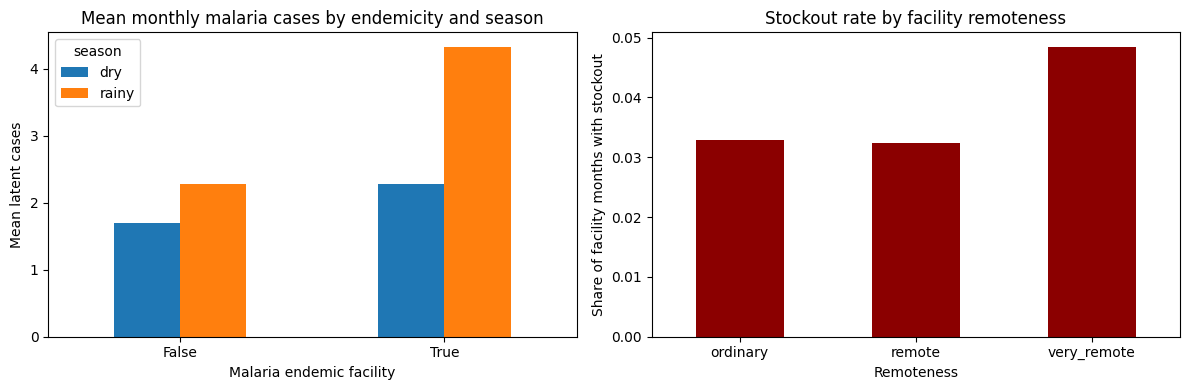

In [20]:
"""Visual diagnostics for the two headline correlations."""

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

malaria_rates.unstack().plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Mean monthly malaria cases by endemicity and season')
axes[0].set_xlabel('Malaria endemic facility')
axes[0].set_ylabel('Mean latent cases')

stockout_rates.reindex(['ordinary', 'remote', 'very_remote']).plot.bar(ax=axes[1], rot=0, color='darkred')
axes[1].set_title('Stockout rate by facility remoteness')
axes[1].set_xlabel('Remoteness')
axes[1].set_ylabel('Share of facility months with stockout')

plt.tight_layout()
plt.show()

In [21]:
"""Final dataset summary for the handoff to Layer 0 and Layer 1."""

summary = {
    'facilities': len(facilities),
    'drugs': len(drugs),
    'conditions': len(conditions),
    'periods': len(PERIODS),
    'diagnosis_rows': len(diagnoses_monthly),
    'stock_rows': len(stock_monthly),
    'anamnesis_records': len(anamnesis_records),
    'anamnesis_per_facility_month': round(
        len(anamnesis_records) / (N_FACILITIES * 12), 2,
    ),
    'overall_stockout_rate': round(float(stock_monthly['stockout_flag'].mean()), 3),
}
for key, value in summary.items():
    print(f'{key:>30}: {value}')

                    facilities: 10
                         drugs: 30
                    conditions: 16
                       periods: 36
                diagnosis_rows: 2104
                    stock_rows: 10800
             anamnesis_records: 273
  anamnesis_per_facility_month: 2.27
         overall_stockout_rate: 0.037
